# EconomIA — Análisis financiero mensual y scoring explicable

*Este notebook es una variante del que crea el resmuen mensual, solo incluye modificcaciones para concretar más el análisis financiero y tenga un mejor orden en las carpteas*.

El funcionamiento de este notebook transforma información de usuarios y transacciones en un resumen mensual, calcula indicadores financieros, genera un **Financial Score explicable** y prepara un dataset para evaluación de Machine Learning.

### Decisiones del proyecto:

- `meta_ahorro` representa la meta declarada por el usuario
- El ahorro real se calcula con las transacciones
- `arquetipo_comportamiento` no se integra al resumen mensual ni al dataset de modelos
- El perfil financiero se obtiene con reglas sobre gasto, ahorro, deuda, balance y control del gasto
- Se generan dos archivos:
  - `monthly_financial_summary.csv`: resumen completo y explicable
  - `monthly_model_dataset.csv`: versión sin las columnas del scoring para reducir fuga de información.
- Se conserva un **bonus de buenos hábitos** de hasta 5 puntos como mecanismo de refuerzo positivo.

Para cada usuario y cada mes se calcula:

- Ingresos:
  - Ingreso total
  - Ingreso base
  - Ingreso variable
- Gastos:
  - Gasto total
  - Gasto por categoría
  - Porcentaje por categoría
- Ahorro:
  - Ahorro mensual
  - Tasa de ahorro
- Deuda
  - Pagos de deuda
  - Porcentaje destinado a deuda
- Comportamiento
  - Número de transacciones
  - Gastos recurrentes
  - Concentración de gastos
  - Balance mensual
- Indicadores
  - Tasa de gasto
  - Tasa de ahorro
  - Tasa de endeudamiento
  - Balance positivo/negativo

In [65]:
# =========
# LIBRERÍAS
# =========

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Carga de archivos

La función busca primero los archivos en Colab, después en `/mnt/data` y finalmente en la carpeta actual.


In [66]:
# =================================================
# FUNCIÓN PARA UBICAR ARCHIVOS DE MANERA AUTOMÁTICA
# =================================================

def find_first_file(file_names):
    folders = [Path('.'), Path('/content'), Path('/mnt/data')]

    for folder in folders:
        for file_name in file_names:
            path = folder / file_name
            if path.exists():
                return path

    raise FileNotFoundError(f"No se encontró ninguno de estos archivos: {file_names}")

USERS_FILE = find_first_file(['users_mejorado.csv','users_v2.csv','users.csv'])
TRANSACTIONS_FILE = find_first_file(['transactions_v2.csv','transactions_mejorado.csv','transactions.csv'])
OUTPUT_DIR = Path('/content') if Path('/content').exists() else Path('/mnt/data')

print('Usuarios:', USERS_FILE)
print('Transacciones:', TRANSACTIONS_FILE)
print('Carpeta de salida:', OUTPUT_DIR)

Usuarios: users.csv
Transacciones: transactions.csv
Carpeta de salida: /content


In [67]:
# ===============
# CARGAR DATASETS
# ===============

users_df = pd.read_csv(USERS_FILE)
transactions_df = pd.read_csv(TRANSACTIONS_FILE)

print("Usuarios:", users_df.shape)
print("Transacciones:", transactions_df.shape)

display(users_df.head(3))
display(transactions_df.head(3))

Usuarios: (300, 14)
Transacciones: (90684, 16)


,user_id,edad,sexo,ocupacion,situacion_vida,ciudad,ingreso_base,ingreso_variable,ingreso_total_estimado,meta_ahorro,frecuencia_ahorro,ratio_deuda_inicial,saldo_deuda_inicial,arquetipo_comportamiento
0,USR_00001,29,F,Médico,Vive solo,Mexicali,"48,369.77","2,369.07","50,738.84",7.56,Baja,0.54,"27,434.49",Ahorrador
1,USR_00002,19,F,Estudiante,Vive con familia,Oaxaca,"4,530.47",228.95,"4,759.42",9.97,Baja,0.44,"2,073.68",Equilibrado
2,USR_00003,20,M,Programador,Vive con familia,Guadalajara,"50,352.29","1,607.84","51,960.13",11.95,Alta,0.58,"29,955.01",Equilibrado


,transaction_id,user_id,fecha,periodo,descripcion,categoria,subcategoria,monto,tipo,metodo_pago,canal,recurrente,origen_generacion,mes,anio,nombre_mes
0,TRX_000000016,USR_00001,2025-01-02,2025-01,Mantenimiento de vivienda,Vivienda,Mantenimiento,528.53,Gasto,Tarjeta de crédito,App bancaria,False,variable,1,2025,Enero
1,TRX_000000011,USR_00001,2025-01-05,2025-01,Compra en tienda,Alimentación,Tiendas,862.89,Gasto,Transferencia,App bancaria,False,variable,1,2025,Enero
2,TRX_000000017,USR_00001,2025-01-05,2025-01,Compra en tienda,Alimentación,Tiendas,"1,560.17",Gasto,Tarjeta de débito,App bancaria,False,variable,1,2025,Enero


## 2. Validación básica

Antes de calcular indicadores, se revisa que los archivos tengan las columnas necesarias y que los usuarios coincidan.


In [68]:
# ==================
# VALIDACIÓN INICIAL
# ==================

def validate(condition, message):
    if not condition:
        raise ValueError(message)


def normalize_user_id(value):
    value = str(value).strip()

    # Compatibilidad con IDs como USR00001 y USR_00001.
    if value.startswith('USR_'): return value
    if value.startswith('USR'): suffix = value.replace('USR', '', 1).replace('_', '')
    if suffix.isdigit(): return f"USR_{int(suffix):05d}"
    return value


users_df['user_id'] = users_df['user_id'].apply(normalize_user_id)
transactions_df['user_id'] = transactions_df['user_id'].apply(normalize_user_id)

required_user_columns = {
    'user_id', 'edad', 'sexo', 'ocupacion', 'situacion_vida', 'ciudad',
    'ingreso_base', 'ingreso_variable', 'ingreso_total_estimado',
    'meta_ahorro', 'frecuencia_ahorro', 'ratio_deuda_inicial',
    'saldo_deuda_inicial'
}

required_transaction_columns = {
    'transaction_id', 'user_id', 'fecha', 'categoria', 'subcategoria',
    'monto', 'tipo', 'recurrente'
}

missing_users = required_user_columns - set(users_df.columns)
missing_transactions = required_transaction_columns - set(transactions_df.columns)

if missing_users:
    legacy_debt = 'nivel_deuda_inicial' in users_df.columns
    extra_message = ''
    if legacy_debt:
        extra_message = (
            " Se detectó 'nivel_deuda_inicial', que pertenece a una versión anterior. "
            "Para el scoring completo usa el dataset con 'ratio_deuda_inicial' y "
            "'saldo_deuda_inicial'. No se convierte automáticamente porque el archivo "
            "no define de forma inequívoca la unidad de esa variable."
        )
    raise ValueError(
        f"Faltan columnas en users: {sorted(missing_users)}.{extra_message}"
    )

validate(not missing_transactions,f"Faltan columnas en transactions: {sorted(missing_transactions)}")

validate(users_df['user_id'].is_unique, 'Hay user_id repetidos.')
validate(transactions_df['transaction_id'].is_unique, 'Hay transaction_id repetidos.')
validate(transactions_df['user_id'].isin(users_df['user_id']).all(),'Hay transacciones con usuarios desconocidos.')
validate(set(users_df['user_id']) == set(transactions_df['user_id']),'No todos los usuarios tienen transacciones.')
validate(transactions_df['monto'].gt(0).all(), 'Hay montos menores o iguales a cero.')

print('Validación inicial superada.')

Validación inicial superada.


## 3. Preparación temporal

Se normalizan las fechas y se construye una estructura con los 12 meses para cada usuario.


In [69]:
# ===============
# PREPARAR FECHAS
# ===============

MONTH_NAMES = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
}

transactions_df["fecha"] = pd.to_datetime(transactions_df["fecha"])
transactions_df["periodo"] = (transactions_df["fecha"].dt.to_period("M").astype(str))
transactions_df["anio"] = transactions_df["fecha"].dt.year
transactions_df["mes"] = transactions_df["fecha"].dt.month
transactions_df["nombre_mes"] = transactions_df["mes"].map(MONTH_NAMES)

START_MONTH = transactions_df["fecha"].min().to_period("M").start_time
END_MONTH = transactions_df["fecha"].max().to_period("M").start_time
MONTHS = pd.date_range(START_MONTH, END_MONTH, freq="MS")

print("Periodo analizado:", START_MONTH.date(), "-", END_MONTH.date())
print("Meses:", len(MONTHS))

Periodo analizado: 2025-01-01 - 2025-12-01
Meses: 12


### Validación de capacidad financiera del dataset

El scoring utiliza deuda y financiamiento como componentes explícitos. Por ello, corroboramos que que las transacciones incluyan esos movimientos para no inflar artifiacialmente el score.

In [70]:
# ===========================================
# VALIDAR MOVIMIENTOS NECESARIOS PARA SCORING
# ===========================================

required_movement_types = {
    'Ingreso',
    'Gasto',
    'Ahorro',
    'Pago deuda',
    'Financiamiento',
}

present_movement_types = set(transactions_df['tipo'].unique())
missing_movement_types = required_movement_types - present_movement_types

validate(
    not missing_movement_types,
    'El dataset de transacciones no permite calcular el scoring completo. '
    f'Faltan tipos de movimiento: {sorted(missing_movement_types)}. '
    'Usa la versión final del generador de transacciones que incluye Deudas y Financiamiento.'
)

validate(
    {'Deudas', 'Finanzas'}.issubset(set(transactions_df['categoria'].unique())),
    "Faltan las categorías 'Deudas' o 'Finanzas' en transactions.",
)

print('El dataset contiene los movimientos necesarios para el scoring.')

El dataset contiene los movimientos necesarios para el scoring.


In [71]:
# ========================
# ESTRUCTURA USUARIO - MES
# ========================

user_month_rows = []

for user_id in users_df["user_id"]:
    for month in MONTHS:
        user_month_rows.append({
            "user_id": user_id,
            "periodo": month.strftime("%Y-%m"),
            "anio": month.year,
            "mes": month.month,
            "nombre_mes": MONTH_NAMES[month.month],
        })

monthly_df = pd.DataFrame(user_month_rows)

print("Registros esperados:", len(users_df) * len(MONTHS))
print("Registros generados:", len(monthly_df))

Registros esperados: 3600
Registros generados: 3600


## 4. Movimientos mensuales

Se suman los ingresos, gastos, pagos de deuda, ahorro, inversiones y financiamiento.


In [72]:
# ==============================
# TOTALES POR TIPO DE MOVIMIENTO
# ==============================

movement_summary = transactions_df.pivot_table(index=["user_id", "periodo"],columns="tipo",values="monto",aggfunc="sum",fill_value=0).reset_index()
movement_summary.columns.name = None
movement_summary = movement_summary.rename(columns={
    "Ingreso": "ingresos",
    "Gasto": "gastos",
    "Pago deuda": "pagos_deuda",
    "Ahorro": "ahorro",
    "Inversión": "inversiones",
    "Financiamiento": "financiamiento"
})

movement_columns = ["ingresos","gastos","pagos_deuda","ahorro","inversiones","financiamiento"]
for column in movement_columns:
  if column not in movement_summary.columns: movement_summary[column] = 0
monthly_df = monthly_df.merge(movement_summary[["user_id", "periodo"] + movement_columns],on=["user_id", "periodo"],how="left")

## 5. Detalle de ingresos y gastos

Esta sección separa:

- Ingreso base e ingreso variable
- Gastos recurrentes y variables
- Número de movimientos y ticket promedio


In [73]:
# =========================
# INGRESOS BASE Y VARIABLES
# =========================

income_data = transactions_df[transactions_df["tipo"] == "Ingreso"]

income_detail = income_data.pivot_table(
    index=["user_id", "periodo"],
    columns="subcategoria",
    values="monto",
    aggfunc="sum",
    fill_value=0
).reset_index()

income_detail.columns.name = None
income_detail = income_detail.rename(columns={"Sueldo": "ingreso_base_real","Variable": "ingreso_variable_real"})

for column in ["ingreso_base_real", "ingreso_variable_real"]:
  if column not in income_detail.columns: income_detail[column] = 0

monthly_df = monthly_df.merge(
    income_detail[["user_id", "periodo", "ingreso_base_real", "ingreso_variable_real"]],on=["user_id", "periodo"],how="left")

In [74]:
# ==============================
# GASTOS RECURRENTES Y VARIABLES
# ==============================

expense_data = transactions_df[transactions_df["tipo"] == "Gasto"].copy()

expense_type = expense_data.pivot_table(
    index=["user_id", "periodo"],
    columns="recurrente",
    values="monto",
    aggfunc="sum",
    fill_value=0
).reset_index()

expense_type.columns.name = None

expense_type = expense_type.rename(columns={True: "gastos_recurrentes",False: "gastos_variables"})

for column in ["gastos_recurrentes", "gastos_variables"]:
    if column not in expense_type.columns:
        expense_type[column] = 0

monthly_df = monthly_df.merge(
    expense_type[["user_id", "periodo", "gastos_recurrentes", "gastos_variables"]],
    on=["user_id", "periodo"],how="left")

In [75]:
# =================
# ACTIVIDAD MENSUAL
# =================

transaction_count = (transactions_df.groupby(["user_id", "periodo"]).agg(numero_transacciones= ("transaction_id", "count")).reset_index())
expense_activity = (expense_data.groupby(["user_id", "periodo"]).agg(numero_gastos= ("transaction_id", "count"),ticket_promedio_gasto= ("monto", "mean")).reset_index())
monthly_df = monthly_df.merge(transaction_count,on= ["user_id", "periodo"],how="left")
monthly_df = monthly_df.merge(expense_activity,on= ["user_id", "periodo"],how="left")

## 6. Gastos por categoría

Las categorías `Deudas` y `Finanzas` no se suman como gasto de consumo porque ya están representadas en pagos de deuda, ahorro, inversión y financiamiento.


In [76]:
# =====================
# GASTOS POR CATEGORÍA
# =====================

CATEGORY_COLUMNS = {
    "Alimentación": "gasto_alimentacion",
    "Transporte": "gasto_transporte",
    "Salud": "gasto_salud",
    "Vivienda": "gasto_vivienda",
    "Educación": "gasto_educacion",
    "Entretenimiento": "gasto_entretenimiento",
    "Servicios": "gasto_servicios",
    "Compras": "gasto_compras",
    "Otros": "gasto_otros"
}

category_summary = expense_data.pivot_table(
    index=["user_id", "periodo"],columns="categoria",values="monto",aggfunc="sum",fill_value=0,).reset_index()

category_summary.columns.name = None
category_summary = category_summary.rename(columns=CATEGORY_COLUMNS)

for column in CATEGORY_COLUMNS.values():
    if column not in category_summary.columns: category_summary[column] = 0

category_amount_columns = list(CATEGORY_COLUMNS.values())

monthly_df = monthly_df.merge(
    category_summary[["user_id", "periodo"] + category_amount_columns],on= ["user_id", "periodo"],how="left")

## 7. Integración de los datos del usuario

Los datos declarados se conservan para comparar la expectativa del usuario con su comportamiento mensual. El arquetipo sintético se elimina.


In [77]:
# ==============
# INTEGRAR USERS
# ==============

user_columns = users_df.drop(columns=["arquetipo_comportamiento"],errors="ignore").copy()
user_columns = user_columns.rename(columns={"ingreso_base": "ingreso_base_estimado","ingreso_variable": "ingreso_variable_estimado"})
monthly_df = monthly_df.merge(user_columns,on="user_id",how="left")
numeric_columns = monthly_df.select_dtypes(include=np.number).columns
monthly_df[numeric_columns] = monthly_df[numeric_columns].fillna(0)

## 8. Indicadores financieros

El balance operativo no considera el nuevo financiamiento como ingreso. Esto permite detectar si el usuario necesitó deuda para cerrar el mes.


In [122]:
# =======================
# CONCENTRACIÓN DEL GASTO
# =======================

monthly_df["categoria_principal"] = (
    monthly_df[category_amount_columns].idxmax(axis=1).str.replace("gasto_", "", regex=False))

monthly_df["gasto_categoria_principal"] = (monthly_df[category_amount_columns].max(axis=1))

monthly_df["concentracion_gasto"] = np.where(
    monthly_df["gastos"] > 0,monthly_df["gasto_categoria_principal"] / monthly_df["gastos"],0)

In [125]:
# ================
# BALANCES Y TASAS
# ================

monthly_df["balance_operativo"] = (
    monthly_df["ingresos"] - monthly_df["gastos"] - monthly_df["pagos_deuda"] - monthly_df["ahorro"] - monthly_df["inversiones"])

monthly_df["saldo_caja"] = (monthly_df["balance_operativo"]+ monthly_df["financiamiento"])
monthly_df["tasa_gasto"] = np.where(monthly_df["ingresos"] > 0,monthly_df["gastos"] / monthly_df["ingresos"],0)
monthly_df["tasa_ahorro"] = np.where(monthly_df["ingresos"] > 0,monthly_df["ahorro"] / monthly_df["ingresos"],0)
monthly_df["tasa_pago_deuda"] = np.where(
    monthly_df["ingresos"] > 0,monthly_df["pagos_deuda"] / monthly_df["ingresos"],0)

monthly_df["tasa_financiamiento"] = np.where(
    monthly_df["ingresos"] > 0,monthly_df["financiamiento"] / monthly_df["ingresos"],0)

monthly_df["tasa_inversion"] = np.where(
    monthly_df["ingresos"] > 0,monthly_df["inversiones"] / monthly_df["ingresos"],0)

monthly_df["tasa_gasto_variable"] = np.where(
    monthly_df["ingresos"] > 0,monthly_df["gastos_variables"] / monthly_df["ingresos"],0)

monthly_df["porcentaje_gasto_recurrente"] = np.where(
    monthly_df["gastos"] > 0,monthly_df["gastos_recurrentes"] / monthly_df["gastos"],0)

monthly_df["cumplimiento_meta_ahorro"] = np.where(
    monthly_df["meta_ahorro"] > 0,monthly_df["tasa_ahorro"] / (monthly_df["meta_ahorro"] / 100),0)

##Para evitar sobre puntajes
monthly_df["cumplimiento_meta_ahorro"] = monthly_df["cumplimiento_meta_ahorro"].clip(0, 1)

monthly_df["desviacion_ingreso_estimado"] = np.where(
    monthly_df["ingreso_total_estimado"] > 0,
    (monthly_df["ingresos"] - monthly_df["ingreso_total_estimado"])
    / monthly_df["ingreso_total_estimado"],0)

## 9. Deuda estimada y comportamiento reciente

El saldo de deuda se estima así: `deuda inicial + financiamiento acumulado -  acumulados`

También se calculan indicadores móviles de tres meses

In [126]:
# =======================
# SALDO DE DEUDA ESTIMADO
# =======================

monthly_df = monthly_df.sort_values(["user_id", "periodo"]).reset_index(drop=True)

monthly_df["saldo_deuda_estimado"] = (
    monthly_df["saldo_deuda_inicial"] + monthly_df.groupby("user_id")["financiamiento"].cumsum()
    - monthly_df.groupby("user_id")["pagos_deuda"].cumsum()
)

monthly_df["saldo_deuda_estimado"] = (monthly_df["saldo_deuda_estimado"].clip(lower=0))

monthly_df["ratio_saldo_deuda_ingreso"] = np.where(
    monthly_df["ingresos"] > 0, monthly_df["saldo_deuda_estimado"] / monthly_df["ingresos"],0)

In [128]:
# =========================
# INDICADORES DE TRES MESES
# =========================

def calculate_income_variation(series):
    rolling_std = series.rolling(3, min_periods=2).std()
    rolling_mean = series.rolling(3, min_periods=2).mean()
    return (rolling_std / rolling_mean).fillna(0)


monthly_df["variacion_ingreso_3m"] = (monthly_df.groupby("user_id")["ingresos"].transform(calculate_income_variation))
monthly_df["promedio_balance_3m"] = (monthly_df.groupby("user_id")["balance_operativo"].transform(lambda values: values.rolling(3, min_periods=1).mean()))
monthly_df["meses_con_financiamiento_3m"] = (monthly_df.groupby("user_id")["financiamiento"].transform(lambda values:(values > 0).astype(int).rolling(3, min_periods=1).sum()).astype(int))

## 10. Scoring financiero explicable

El score máximo es 100 puntos:

| Componente | Puntos máximos |
|---|---:|
| Nivel de gasto | 25 |
| Cumplimiento de ahorro | 25 |
| Nivel de deuda | 20 |
| Necesidad de financiamiento | 20 |
| Control de gasto variable | 10 |

Clasificación:

- **Saludable:** 75 a 100
- **En observación:** 50 a 74
- **En riesgo:** menos de 50

In [129]:
# =====================
# FUNCIONES DEL SCORING
# =====================
def points_spending(rate):
    # Menor presión de gasto
    if rate <= 0.60:
        return 25
    # Reducción progresiva entre 60% y 100%
    elif rate <= 1.00:
        return round(
            25 * (1 - ((rate - 0.60) / 0.40)), 2)
    # Gastos superiores al ingreso
    else:
        return 0

def points_saving(compliance):
    # No se premia más allá de cumplir la meta
    compliance = min(compliance, 1)
    return round(compliance * 25, 2)

def points_debt(debt_ratio):
    # Bajo nivel de deuda
    if debt_ratio <= 0.25:
        return 20
    # Pérdida progresiva hasta una relación deuda/ingreso de 2
    elif debt_ratio <= 2.00:
        return round(
            20 * (1 - ((debt_ratio - 0.25) / 1.75)),2)
    else:
        return 0

def points_balance(financing_rate):
    # No requiere financiamiento externo
    if financing_rate <= 0:
        return 20
    # Penalización progresiva hasta 20%
    elif financing_rate <= 0.20:
        return round(20 * (1 -(financing_rate / 0.20)),2)
    else:
        return 0

def points_control(variable_expense_rate):
    # Bajo gasto variable
    if variable_expense_rate <= 0.35:
        return 10
    # Penalización progresiva
    elif variable_expense_rate <= 0.65:
        return round(
            10 * (1 - ((variable_expense_rate - 0.35) / 0.30)),2)
    else:
        return 0

In [131]:
# =======================
# CALCULAR SCORE Y PERFIL
# =======================

monthly_df["puntos_gasto"] = monthly_df["tasa_gasto"].apply(points_spending)
monthly_df["puntos_ahorro"] = monthly_df["cumplimiento_meta_ahorro"].apply(points_saving)
monthly_df["puntos_deuda"] = monthly_df["ratio_saldo_deuda_ingreso"].apply(points_debt)
monthly_df["puntos_balance"] = monthly_df["tasa_financiamiento"].apply(points_balance)
monthly_df["puntos_control"] = monthly_df["tasa_gasto_variable"].apply(points_control)

score_columns = ["puntos_gasto","puntos_ahorro","puntos_deuda","puntos_balance","puntos_control"]

# Score técnico antes del bonus. Los cinco componentes principales suman un máximo de 100 puntos.
monthly_df["score_base"] = (monthly_df[score_columns].sum(axis=1).round(2))


# =======================
# BONUS DE BUENOS HÁBITOS
# =======================
# El bonus funciona como refuerzo positivo. No sustituye los componentes principales del score.
# Puede aportar hasta 5 puntos, manteniendo el resultado final en 100.

def bonus_score(row):
    bonus = 0
    # Cumplió o superó su meta de ahorro.
    if row["cumplimiento_meta_ahorro"] >= 1:
        bonus += 2
    # No necesitó nuevo financiamiento durante el mes.
    if row["tasa_financiamiento"] == 0:
        bonus += 2
    # Mantuvo el gasto variable por debajo del 30 % del ingreso.
    if row["tasa_gasto_variable"] < 0.30:
        bonus += 1
    return bonus


def bonus_reasons(row):
    reasons = []
    if row["cumplimiento_meta_ahorro"] >= 1:
        reasons.append("Meta de ahorro cumplida")
    if row["tasa_financiamiento"] == 0:
        reasons.append("Sin nuevo financiamiento")
    if row["tasa_gasto_variable"] < 0.30:
        reasons.append("Buen control del gasto variable")
    if not reasons:
        return "Sin bonus este mes"
    return " | ".join(reasons)

monthly_df["bonus_buenos_habitos"] = (monthly_df.apply(bonus_score, axis=1))
monthly_df["motivos_bonus"] = (monthly_df.apply(bonus_reasons, axis=1))
# Score final limitado a 100.
monthly_df["score_financiero"] = (monthly_df["score_base"]+ monthly_df["bonus_buenos_habitos"]).clip(upper=100).round(2)
# Bonus realmente aplicado después del límite de 100.
# Ejemplo: score_base = 98 y bonus_obtenido = 5 -> bonus_aplicado = 2.
monthly_df["bonus_aplicado"] = (monthly_df["score_financiero"]- monthly_df["score_base"]).round(2)


# ======
# PERFIL
# ======

def assign_profile(score):
    if score >= 75:
        return "Saludable"
    if score >= 50:
        return "En observación"
    return "En riesgo"


monthly_df["perfil_financiero"] = (monthly_df["score_financiero"].apply(assign_profile))

## 11. Diagnóstico principal y recomendación

- El perfil indica el nivel general
- El diagnóstico identifica el principal punto de atención del mes


In [132]:
# =====================
# DIAGNÓSTICO PRINCIPAL
# =====================

def assign_diagnosis(row):
    if row["tasa_financiamiento"] > 0: return "Déficit y financiamiento"
    if (row["ratio_saldo_deuda_ingreso"] > 0.35 or row["tasa_pago_deuda"] > 0.12): return "Endeudamiento"
    if (row["tasa_gasto"] > 0.90 or row["tasa_gasto_variable"] > 0.60): return "Gasto elevado"
    if row["cumplimiento_meta_ahorro"] < 0.50: return "Ahorro insuficiente"
    if row["variacion_ingreso_3m"] > 0.15: return "Ingresos inestables"
    return "Equilibrado"

monthly_df["diagnostico_principal"] = (monthly_df.apply(assign_diagnosis, axis=1))

RECOMMENDATIONS = {
    "Déficit y financiamiento": "Reducir gastos variables y evitar nuevo financiamiento.",
    "Endeudamiento": "Priorizar pagos de deuda y limitar nuevas compras a crédito.",
    "Gasto elevado": "Revisar los gastos variables y la categoría principal del mes.",
    "Ahorro insuficiente": "Programar un ahorro automático para acercarse a la meta declarada.",
    "Ingresos inestables": "Presupuestar con el ingreso base y fortalecer el fondo de emergencia.",
    "Equilibrado": "Mantener el control actual y continuar con el hábito de ahorro."
}

monthly_df["recomendacion_base"] = (monthly_df["diagnostico_principal"].map(RECOMMENDATIONS))

## 12. Orden final de columnas

El resumen completo incluye el score y sus componentes para poder explicar cada clasificación.


In [133]:
identifier_columns = [
    "user_id",
    "periodo",
    "anio",
    "mes",
    "nombre_mes"
]

result_columns = [
    "perfil_financiero",
    "score_base",
    "bonus_buenos_habitos",
    "bonus_aplicado",
    "motivos_bonus",
    "score_financiero",
    "diagnostico_principal",
    "recomendacion_base"
]

user_information_columns = [
    "edad",
    "sexo",
    "ocupacion",
    "situacion_vida",
    "ciudad",
    "ingreso_base_estimado",
    "ingreso_variable_estimado",
    "ingreso_total_estimado",
    "meta_ahorro",
    "frecuencia_ahorro",
    "ratio_deuda_inicial",
    "saldo_deuda_inicial"
]

movement_columns = [
    "ingreso_base_real",
    "ingreso_variable_real",
    "ingresos",
    "gastos",
    "gastos_recurrentes",
    "gastos_variables",
    "pagos_deuda",
    "ahorro",
    "inversiones",
    "financiamiento",
    "numero_transacciones",
    "numero_gastos",
    "ticket_promedio_gasto"
]

indicator_columns = [
    "categoria_principal",
    "gasto_categoria_principal",
    "concentracion_gasto",
    "balance_operativo",
    "saldo_caja",
    "tasa_gasto",
    "tasa_ahorro",
    "tasa_pago_deuda",
    "tasa_financiamiento",
    "tasa_inversion",
    "tasa_gasto_variable",
    "porcentaje_gasto_recurrente",
    "cumplimiento_meta_ahorro",
    "desviacion_ingreso_estimado",
    "saldo_deuda_estimado",
    "ratio_saldo_deuda_ingreso",
    "variacion_ingreso_3m",
    "promedio_balance_3m",
    "meses_con_financiamiento_3m"
]

scoring_columns = [
    "puntos_gasto",
    "puntos_ahorro",
    "puntos_deuda",
    "puntos_balance",
    "puntos_control"
]

final_columns = (
    identifier_columns
    + result_columns
    + user_information_columns
    + movement_columns
    + category_amount_columns
    + indicator_columns
    + scoring_columns
)

monthly_financial_summary = monthly_df[final_columns].copy()

print("Dimensiones del resumen:", monthly_financial_summary.shape)
monthly_financial_summary.sample(5)

Dimensiones del resumen: (3600, 71)


,user_id,periodo,anio,mes,nombre_mes,perfil_financiero,score_base,bonus_buenos_habitos,bonus_aplicado,motivos_bonus,score_financiero,diagnostico_principal,recomendacion_base,edad,sexo,ocupacion,situacion_vida,ciudad,ingreso_base_estimado,ingreso_variable_estimado,ingreso_total_estimado,meta_ahorro,frecuencia_ahorro,ratio_deuda_inicial,saldo_deuda_inicial,ingreso_base_real,ingreso_variable_real,ingresos,gastos,gastos_recurrentes,gastos_variables,pagos_deuda,ahorro,inversiones,financiamiento,numero_transacciones,numero_gastos,ticket_promedio_gasto,gasto_alimentacion,gasto_transporte,gasto_salud,gasto_vivienda,gasto_educacion,gasto_entretenimiento,gasto_servicios,gasto_compras,gasto_otros,categoria_principal,gasto_categoria_principal,concentracion_gasto,balance_operativo,saldo_caja,tasa_gasto,tasa_ahorro,tasa_pago_deuda,tasa_financiamiento,tasa_inversion,tasa_gasto_variable,porcentaje_gasto_recurrente,cumplimiento_meta_ahorro,desviacion_ingreso_estimado,saldo_deuda_estimado,ratio_saldo_deuda_ingreso,variacion_ingreso_3m,promedio_balance_3m,meses_con_financiamiento_3m,puntos_gasto,puntos_ahorro,puntos_deuda,puntos_balance,puntos_control
2187,USR_00183,2025-04,2025,4,Abril,Saludable,96.64,2,2.00,Sin nuevo financiamiento,98.64,Equilibrado,Mantener el control actual y continuar con el ...,49,M,Profesor,Vive con pareja,Monterrey,"23,541.85","1,439.53","24,981.38",26.21,Baja,0.08,"2,105.93","22,731.18","1,174.03","23,905.21","13,970.90","5,592.61","8,378.29",0.00,"5,429.10",0.00,0.00,22,19,735.31,"2,437.40",806.31,944.47,"4,792.78",0.00,"1,762.33","2,522.35",705.26,0.00,vivienda,"4,792.78",0.34,"4,505.21","4,505.21",0.58,0.23,0.00,0.00,0.00,0.35,0.40,0.87,-0.04,0.00,0.00,0.02,"5,446.31",0,25.00,21.66,20.00,20.00,9.98
1788,USR_00150,2025-01,2025,1,Enero,Saludable,83.52,2,2.00,Sin nuevo financiamiento,85.52,Endeudamiento,Priorizar pagos de deuda y limitar nuevas comp...,23,M,Estudiante,Vive con familia,Pachuca,"8,519.64",293.76,"8,813.40",20.71,Baja,0.45,"4,004.81","8,054.80",217.33,"8,272.13","5,592.27","1,946.87","3,645.40",445.35,"1,257.20",0.00,0.00,20,16,349.52,728.27,591.26,636.13,"1,300.75","1,276.48",471.75,422.75,164.88,0.00,vivienda,"1,300.75",0.23,977.31,977.31,0.68,0.15,0.05,0.00,0.00,0.44,0.35,0.73,-0.06,"3,559.46",0.43,0.00,977.31,0,20.25,18.35,17.94,20.00,6.98
3203,USR_00267,2025-12,2025,12,Diciembre,En riesgo,31.68,0,0.00,Sin bonus este mes,31.68,Déficit y financiamiento,Reducir gastos variables y evitar nuevo financ...,26,M,Comerciante,Vive con pareja,Xalapa,"20,448.13","8,768.69","29,216.82",5.02,Media,0.16,"4,712.67","18,101.92","11,879.67","29,981.59","30,609.42","7,356.19","23,253.23","1,867.63",0.00,0.00,"2,495.45",28,24,"1,275.39","8,591.85","3,440.28",519.52,"5,101.16","1,197.54","3,028.20","4,914.37","3,816.50",0.00,alimentacion,"8,591.85",0.28,"-2,495.46",-0.01,1.02,0.00,0.06,0.08,0.00,0.78,0.24,0.00,0.03,"3,205.09",0.11,0.22,"-1,689.38",2,0.00,0.00,20.00,11.68,0.00
2059,USR_00172,2025-08,2025,8,Agosto,En observación,59.98,2,2.00,Sin nuevo financiamiento,61.98,Gasto elevado,Revisar los gastos variables y la categoría pr...,36,O,Ejecutivo,Vive con pareja,Toluca,"81,911.59","7,641.90","89,553.49",11.20,Alta,0.08,"6,967.26","82,530.08","7,461.55","89,991.63","79,183.98","18,968.19","60,215.79","4,674.87","5,028.88",0.00,0.00,35,31,"2,554.32","14,288.64","16,817.67","4,169.47","13,741.19","2,786.38","7,588.26","11,369.22","3,467.71","4,955.44",transporte,"16,817.67",0.21,"1,103.90","1,103.90",0.88,0.06,0.05,0.00,0.00,0.67,0.24,0.50,0.00,0.00,0.00,0.04,"1,115.76",1,7.51,12.47,20.00,20.00,0.00
648,USR_00055,2025-01,2025,1,Enero,En observación,69.30,2,2.00,Sin nuevo financiamiento,71.30,Gasto elevado,Revisar los gastos variables y la categoría pr...,53,M,Ingeniero,Vive con familia,Hermosillo,"15,678.42",845.72,"16,524.14",13.75,Baja,0.09,"1,449.17","15,655.58",858.71,"16,514.29","12,848.97","2,366.10","10,482.87","1,107.19","1,355.57",0.00,0.00,24,20,642.45,"2,775.00",61.96,"3,737.74",832.85,0.00,"1,199.79","1,096.15",

## 13. Validaciones finales

Se comprueba que:

- Exista una fila por usuario y mes
- No haya valores nulos
- El gasto coincida con sus categorías
- El gasto coincida con recurrente más variable
- El score esté entre 0 y 100
- Existan las tres clases financieras
- El arquetipo no aparezca en el resultado


In [134]:
expected_rows = len(users_df) * len(MONTHS)
validate(len(monthly_financial_summary) == expected_rows,"El número de registros usuario-mes es incorrecto.")
validate(not monthly_financial_summary.duplicated(["user_id", "periodo"]).any(),"Hay registros usuario-mes repetidos.")
validate(monthly_financial_summary.isna().sum().sum() == 0,"El resumen mensual tiene valores nulos.")
validate(monthly_financial_summary["ingresos"].gt(0).all(),"Hay meses sin ingresos.")

category_difference = (monthly_financial_summary[category_amount_columns].sum(axis=1)- monthly_financial_summary["gastos"]).abs()
validate(category_difference.le(0.10).all(),"El gasto total no coincide con el gasto por categorías.")

expense_type_difference = (monthly_financial_summary["gastos_recurrentes"]+ monthly_financial_summary["gastos_variables"]- monthly_financial_summary["gastos"]).abs()
validate(expense_type_difference.le(0.10).all(),"El gasto total no coincide con recurrente más variable.")
validate(monthly_financial_summary["saldo_caja"].ge(-0.10).all(),"Hay déficits que no quedaron cubiertos por financiamiento.")
validate(monthly_financial_summary["score_base"].between(0, 100).all(),"Hay scores base fuera del rango 0-100.")
validate(monthly_financial_summary["bonus_buenos_habitos"].between(0, 5).all(),"Hay bonus fuera del rango 0-5.")
validate(monthly_financial_summary["bonus_aplicado"].between(0, 5).all(),"Hay bonus aplicados fuera del rango 0-5.")
validate(monthly_financial_summary["score_financiero"].between(0, 100).all(),"Hay scores finales fuera del rango 0-100.")

# Verificar score base.
score_base_difference = (
    monthly_financial_summary[scoring_columns].sum(axis=1)
    - monthly_financial_summary["score_base"]
).abs()

validate(
    score_base_difference.le(0.01).all(),
    "El score base no coincide con la suma de sus cinco componentes.",
)

# Verificar bonus y límite de 100.
expected_final_score = (
    monthly_financial_summary["score_base"]
    + monthly_financial_summary["bonus_buenos_habitos"]
).clip(upper=100).round(2)

validate(
    expected_final_score.eq(
        monthly_financial_summary["score_financiero"]
    ).all(),
    "El score final no coincide con score base + bonus limitado a 100.",
)

expected_bonus_applied = (
    monthly_financial_summary["score_financiero"]
    - monthly_financial_summary["score_base"]
).round(2)

validate(
    expected_bonus_applied.eq(
        monthly_financial_summary["bonus_aplicado"]
    ).all(),
    "El bonus aplicado no es coherente con el score final.",
)

expected_profiles = {
    "Saludable",
    "En observación",
    "En riesgo",
}

validate(
    expected_profiles.issubset(
        set(monthly_financial_summary["perfil_financiero"])
    ),
    "No se generaron las tres clases financieras.",
)

expected_profile_from_score = (
    monthly_financial_summary["score_financiero"]
    .apply(assign_profile)
)

validate(
    expected_profile_from_score.eq(
        monthly_financial_summary["perfil_financiero"]
    ).all(),
    "Hay perfiles que no coinciden con los umbrales 75/50.",
)

validate(
    "arquetipo_comportamiento"
    not in monthly_financial_summary.columns,
    "El arquetipo no debe aparecer en el resumen mensual.",
)

print("Todas las validaciones fueron superadas.")
print("Coherencia interna del score base, bonus y score final validada.")

Todas las validaciones fueron superadas.
Coherencia interna del score base, bonus y score final validada.


## 14. Dataset para modelos

La versión para modelos conserva las variables financieras y las etiquetas, pero elimina:

- Componentes del scoring
- Score financiero
- Recomendación textual

`user_id` y `periodo` se conservan para separar usuarios y meses, pero no deben usarse como variables predictoras.


In [137]:
# ============================================
# DATASETS PARA EVALUACIÓN DE MACHINE LEARNING
# ============================================

# Variables derivadas directamente del scoring o del bonus.
# Se eliminan para evitar data leakage.
scoring_leakage_columns = [
    "score_base",
    "score_financiero",
    "bonus_buenos_habitos",
    "bonus_aplicado",
    "motivos_bonus",
    "puntos_gasto",
    "puntos_ahorro",
    "puntos_deuda",
    "puntos_balance",
    "puntos_control",
    "recomendacion_base"
]

monthly_model_dataset = (monthly_financial_summary.drop(columns=scoring_leakage_columns).copy())

# Dataset específico para estudiar la predicción del perfil.
# También se elimina diagnóstico porque es otra salida derivada de reglas financieras del mismo mes.
profile_model_dataset = (monthly_model_dataset.drop(columns=["diagnostico_principal"],errors="ignore").copy())
validate("arquetipo_comportamiento"not in monthly_model_dataset.columns,"El arquetipo apareció en el dataset de modelos.")

for leakage_column in scoring_leakage_columns:
    validate(leakage_column not in monthly_model_dataset.columns,f"{leakage_column} no debe entrar como feature del modelo.")

validate("diagnostico_principal"not in profile_model_dataset.columns,"El diagnóstico no debe entrar como feature al predecir el perfil.")

print("Dataset completo:", monthly_financial_summary.shape)
print("Dataset general para modelos:", monthly_model_dataset.shape)
print("Dataset para benchmark de perfil:", profile_model_dataset.shape)

Dataset completo: (3600, 71)
Dataset general para modelos: (3600, 60)
Dataset para benchmark de perfil: (3600, 59)


## 15. Redondeo y exportación


In [139]:
# ====================
# REDONDEAR RESULTADOS
# ====================

money_columns = [
    "ingreso_base_estimado","ingreso_variable_estimado","ingreso_total_estimado",
    "saldo_deuda_inicial","ingreso_base_real","ingreso_variable_real","ingresos",
    "gastos","gastos_recurrentes","gastos_variables","pagos_deuda","ahorro",
    "inversiones","financiamiento","ticket_promedio_gasto","gasto_categoria_principal",
    "balance_operativo","saldo_caja","saldo_deuda_estimado","promedio_balance_3m"] + category_amount_columns

rate_columns = [
    "ratio_deuda_inicial","concentracion_gasto","tasa_gasto","tasa_ahorro",
    "tasa_pago_deuda","tasa_financiamiento","tasa_inversion","tasa_gasto_variable",
    "porcentaje_gasto_recurrente","cumplimiento_meta_ahorro","desviacion_ingreso_estimado",
    "ratio_saldo_deuda_ingreso","variacion_ingreso_3m"]

for column in money_columns:
    monthly_financial_summary[column] = (monthly_financial_summary[column].round(2))

    if column in monthly_model_dataset.columns:
        monthly_model_dataset[column] = monthly_model_dataset[column].round(2)
    if column in profile_model_dataset.columns:
        profile_model_dataset[column] = profile_model_dataset[column].round(2)

for column in rate_columns:
    monthly_financial_summary[column] = (monthly_financial_summary[column].round(4))

    if column in monthly_model_dataset.columns:
        monthly_model_dataset[column] = monthly_model_dataset[column].round(4)
    if column in profile_model_dataset.columns:
        profile_model_dataset[column] = profile_model_dataset[column].round(4)

In [155]:
# =================
# EXPORTAR ARCHIVOS
# =================

summary_path = OUTPUT_DIR / "monthly_financial_summary_final.csv"
model_path = OUTPUT_DIR / "monthly_model_dataset_final.csv"
profile_model_path = OUTPUT_DIR / "monthly_profile_model_dataset_final.csv"

monthly_financial_summary.to_csv(summary_path,index=False,encoding="utf-8-sig")
monthly_model_dataset.to_csv(model_path,index=False,encoding="utf-8-sig")
profile_model_dataset.to_csv(profile_model_path,index=False,encoding="utf-8-sig",)

profile_audit = (
    monthly_financial_summary.groupby("perfil_financiero")
    .agg(
        registros=("user_id", "size"),
        usuarios=("user_id", "nunique"),
        score_base_promedio=("score_base", "mean"),
        bonus_promedio=("bonus_buenos_habitos", "mean"),
        score_promedio=("score_financiero", "mean"),
        tasa_gasto_promedio=("tasa_gasto", "mean"),
        tasa_ahorro_promedio=("tasa_ahorro", "mean"),
        tasa_financiamiento_promedio=("tasa_financiamiento", "mean"),
        saldo_deuda_promedio=("saldo_deuda_estimado", "mean"),
    )
    .reset_index())

print("Archivos generados:")
print(summary_path)
print(model_path)
print(profile_model_path)

Archivos generados:
/content/monthly_financial_summary_final.csv
/content/monthly_model_dataset_final.csv
/content/monthly_profile_model_dataset_final.csv


In [141]:
# ========================
# DISTRIBUCIÓN DE PERFILES
# ========================

profile_distribution = (
    monthly_financial_summary["perfil_financiero"].value_counts().rename_axis("perfil_financiero").reset_index(name="registros"))

diagnosis_distribution = (
    monthly_financial_summary["diagnostico_principal"].value_counts().rename_axis("diagnostico_principal").reset_index(name="registros"))

display(profile_distribution)
display(diagnosis_distribution)
display(profile_audit.round(4))

,perfil_financiero,registros
0,Saludable,1793
1,En observación,1128
2,En riesgo,679


,diagnostico_principal,registros
0,Equilibrado,1430
1,Ahorro insuficiente,724
2,Gasto elevado,526
3,Déficit y financiamiento,519
4,Endeudamiento,292
5,Ingresos inestables,109


,perfil_financiero,registros,usuarios,score_base_promedio,bonus_promedio,score_promedio,tasa_gasto_promedio,tasa_ahorro_promedio,tasa_financiamiento_promedio,saldo_deuda_promedio
0,En observación,1128,270,63.07,2.01,65.08,0.76,0.03,0.00,"3,761.96"
1,En riesgo,679,98,35.11,0.47,35.58,1.00,0.00,0.06,"8,772.25"
2,Saludable,1793,241,87.25,2.89,89.67,0.67,0.14,0.00,"3,235.23"


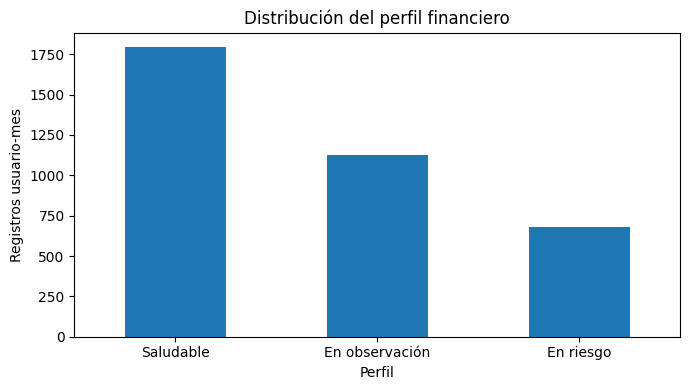

In [142]:
# Gráfica para revisar el balance de clases

profile_counts = (monthly_financial_summary["perfil_financiero"].value_counts())

plt.figure(figsize=(7, 4))
profile_counts.plot(kind="bar")
plt.title("Distribución del perfil financiero")
plt.xlabel("Perfil")
plt.ylabel("Registros usuario-mes")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

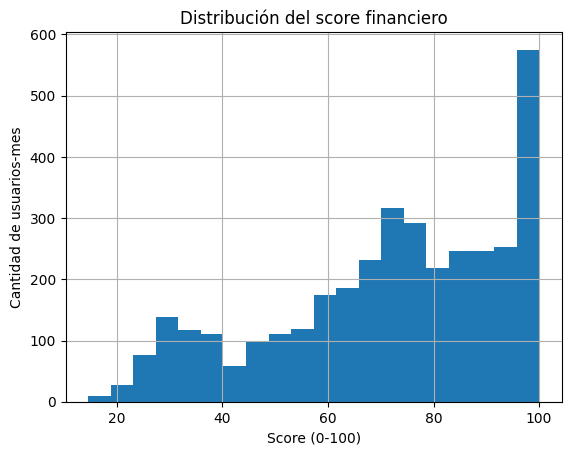

In [143]:
#Distribución del Score Financiero
monthly_financial_summary["score_financiero"].hist(bins=20)
plt.title("Distribución del score financiero")
plt.xlabel("Score (0-100)")
plt.ylabel("Cantidad de usuarios-mes")
plt.show()

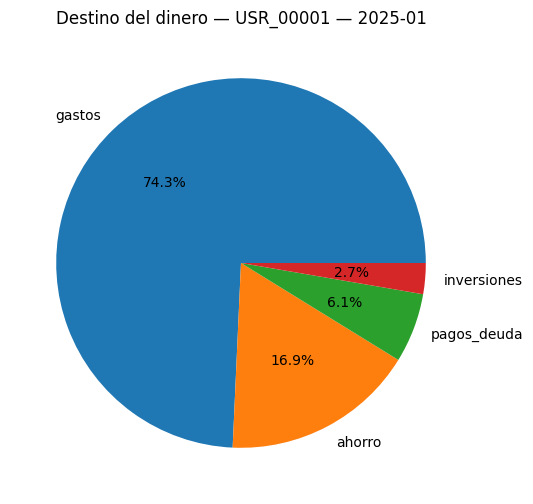

In [145]:
# Distribución del dinero de un usuario-mes
user_id_ejemplo = monthly_financial_summary['user_id'].iloc[0]
periodo_ejemplo = monthly_financial_summary.loc[monthly_financial_summary['user_id'] == user_id_ejemplo,'periodo'].iloc[0]
fila = monthly_financial_summary[(monthly_financial_summary['user_id'] == user_id_ejemplo)& (monthly_financial_summary['periodo'] == periodo_ejemplo)]
destino = fila[['gastos', 'ahorro', 'pagos_deuda', 'inversiones']].iloc[0]
destino = destino[destino > 0]

plt.figure(figsize=(6, 6))
plt.pie(destino, labels=destino.index, autopct='%1.1f%%')
plt.title(f'Destino del dinero — {user_id_ejemplo} — {periodo_ejemplo}')
plt.show()

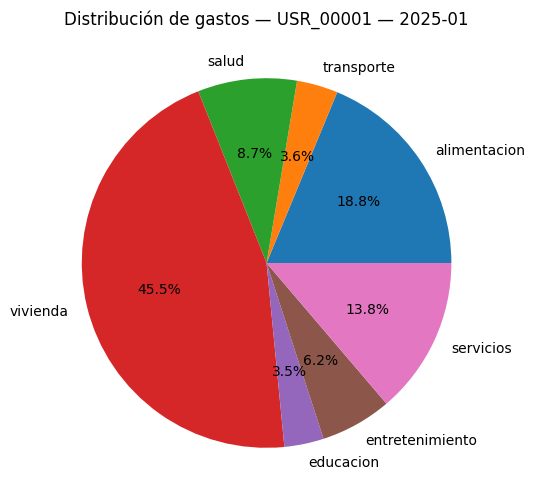

In [146]:
# Distribución de gasto por categoría para un usuario-mes
user_id_ejemplo = monthly_financial_summary['user_id'].iloc[0]
periodo_ejemplo = monthly_financial_summary.loc[
    monthly_financial_summary['user_id'] == user_id_ejemplo,
    'periodo'
].iloc[0]

fila = monthly_financial_summary[
    (monthly_financial_summary['user_id'] == user_id_ejemplo)
    & (monthly_financial_summary['periodo'] == periodo_ejemplo)
]

gastos_categoria = fila[category_amount_columns].iloc[0]
gastos_categoria = gastos_categoria[gastos_categoria > 0]
gastos_categoria.index = gastos_categoria.index.str.replace('gasto_', '', regex=False)

plt.figure(figsize=(6, 6))
plt.pie(gastos_categoria, labels=gastos_categoria.index, autopct='%1.1f%%')
plt.title(f'Distribución de gastos — {user_id_ejemplo} — {periodo_ejemplo}')
plt.show()

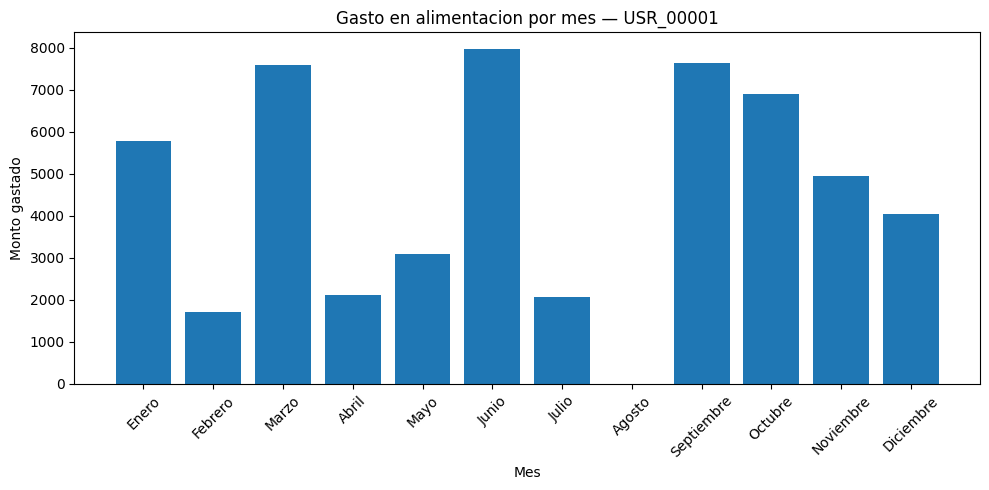

In [147]:
# Evolución de gasto por categoría
user_id_ejemplo = monthly_financial_summary['user_id'].iloc[0]
categoria_ejemplo = 'alimentacion'
columna_categoria = 'gasto_' + categoria_ejemplo

datos_usuario = monthly_financial_summary[
    monthly_financial_summary['user_id'] == user_id_ejemplo
].sort_values('periodo')

plt.figure(figsize=(10, 5))
plt.bar(datos_usuario['nombre_mes'], datos_usuario[columna_categoria])
plt.title(f'Gasto en {categoria_ejemplo} por mes — {user_id_ejemplo}')
plt.xlabel('Mes')
plt.ylabel('Monto gastado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 17. Benchmark de ML

Esta sección **no reemplaza el scoring**.

El target `perfil_financiero` fue creado mediante reglas que incluyen:

- Cinco componentes financieros principales
- Un bonus de buenos hábitos de hasta 5 puntos
- Límite final de 100 puntos

Por lo tanto, un clasificador entrenado con indicadores del mismo mes aprenderá principalmente a aproximar esas reglas.

El benchmark sirve para:

- Comprobar que el dataset puede alimentar un pipeline de ML
- Practicar separación correcta por usuario
- Medir qué tan reproducible es la clasificación
- Documentar por qué el scoring explicable sigue siendo la opción de producto para el MVP


In [148]:
# ==============================
# LIBRERÍAS PARA BENCHMARK DE ML
# ==============================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

In [149]:
# =====================================
# PREPARAR FEATURES Y SPLIT POR USUARIO
# =====================================

target = 'perfil_financiero'

# IDs y columnas temporales se conservan para trazabilidad, pero no son features.
non_feature_columns = ['user_id', 'periodo', 'nombre_mes', target]

X = profile_model_dataset.drop(columns=non_feature_columns, errors='ignore').copy()
y = profile_model_dataset[target].copy()
groups = profile_model_dataset['user_id'].copy()

splitter = GroupShuffleSplit(n_splits=1,test_size=0.20,random_state=42)
train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train_ml = X.iloc[train_index]
X_test_ml = X.iloc[test_index]
y_train_ml = y.iloc[train_index]
y_test_ml = y.iloc[test_index]

train_users = set(groups.iloc[train_index])
test_users = set(groups.iloc[test_index])

validate(train_users.isdisjoint(test_users), 'Hay usuarios compartidos entre train y test.')

print('Usuarios train:', len(train_users))
print('Usuarios test:', len(test_users))
print('Filas train:', len(X_train_ml))
print('Filas test:', len(X_test_ml))

Usuarios train: 240
Usuarios test: 60
Filas train: 2880
Filas test: 720


In [150]:
# ==========================
# PREPROCESAMIENTO Y MODELOS
# ==========================

numeric_features = X_train_ml.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train_ml.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),('scaler', StandardScaler())])
categorical_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('numeric', numeric_pipeline, numeric_features),('categorical', categorical_pipeline, categorical_features)])

benchmark_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2500,
        class_weight='balanced',
        random_state=42,
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=250,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1,
    ),
}

In [151]:
# ===================
# ENTRENAR Y COMPARAR
# ===================

benchmark_rows = []
trained_benchmarks = {}

for model_name, model in benchmark_models.items():
    pipeline = Pipeline([('preprocessor', preprocessor),('model', model)])

    pipeline.fit(X_train_ml, y_train_ml)
    prediction = pipeline.predict(X_test_ml)

    benchmark_rows.append({
        'modelo': model_name,
        'accuracy_test': accuracy_score(y_test_ml, prediction),
        'f1_macro_test': f1_score(y_test_ml, prediction, average='macro')
    })

    trained_benchmarks[model_name] = pipeline

benchmark_results = (pd.DataFrame(benchmark_rows).sort_values('f1_macro_test', ascending=False).reset_index(drop=True))
display(benchmark_results.round(4))

,modelo,accuracy_test,f1_macro_test
0,Logistic Regression,0.97,0.97
1,Random Forest,0.96,0.95


In [153]:
# ===================================
# REPORTE Y EXPORTACIÓN DEL BENCHMARK
# ===================================

best_benchmark_name = benchmark_results.loc[0, 'modelo']
best_benchmark = trained_benchmarks[best_benchmark_name]
best_prediction = best_benchmark.predict(X_test_ml)

print('Mejor benchmark:', best_benchmark_name)
display(pd.DataFrame(classification_report(y_test_ml,best_prediction,output_dict=True,zero_division=0)).transpose().round(4))
benchmark_path = OUTPUT_DIR / 'financial_profile_benchmark.joblib'

joblib.dump(best_benchmark, benchmark_path)
print(benchmark_path)

Mejor benchmark: Logistic Regression


,precision,recall,f1-score,support
En observación,0.92,0.96,0.94,194.00
En riesgo,0.97,1.00,0.99,168.00
Saludable,0.99,0.96,0.97,358.00
accuracy,0.97,0.97,0.97,0.97
macro avg,0.96,0.97,0.97,720.00
weighted avg,0.97,0.97,0.97,720.00


/content/financial_profile_benchmark.joblib


### Interpretación del benchmark

Un desempeño alto **no demuestra que el modelo haya descubierto riesgo financiero real**: la etiqueta fue creada por el mismo scoring. Por esa razón, el resultado se documenta como benchmark técnico y no como sustituto del motor explicable.

Para un modelo financiero verdaderamente predictivo se necesitarían etiquetas externas o futuras, por ejemplo mora, incumplimiento, deterioro financiero posterior o evaluación experta.

## Resultado final

El notebook deja terminados dos productos:

1. **Motor financiero explicable**: resumen mensual, score, perfil, diagnóstico y recomendación.
2. **Benchmark experimental de ML**: demuestra que el dataset puede alimentar un clasificador, manteniendo separación por usuario y sin componentes directos del score.

Para el MVP, el resultado oficial recomendado sigue siendo el scoring basado en reglas. El benchmark se conserva como evidencia técnica y punto de comparación para futuras etiquetas reales.